# PCA Local Neighborhoods Approach to Bulk Covariance Estimate

In [67]:
# Load in CoBaLT data

# Imports and project root setup
import sys
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
import time
import hdbscan
from sklearn.decomposition import PCA
import torch
import numpy as np
from sklearn.cluster import KMeans
from torch.distributions import MultivariateNormal
from sklearn.neighbors import NearestNeighbors

# Determine project root: prefer __file__ when available (script), otherwise search upward for 'config/preprocessing.yaml'
def find_project_root(start_path: Path = Path.cwd()):
    p = start_path.resolve()
    for parent in [p] + list(p.parents):
        if (parent / 'config' / 'preprocessing.yaml').exists():
            return parent
    return start_path.resolve()

try:
    project_root = Path(__file__).resolve().parent.parent
except NameError:
    project_root = find_project_root()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# (Optional) configure matplotlib interactive backend, if you want interactive selectors in this notebook
# Uncomment one of the following depending on your environment:
# %matplotlib widget
# %matplotlib notebook
%matplotlib inline

# Import the DataPreprocessor class from the package
from processing.data_preprocessor_v2 import DataPreprocessor
from processing.processing_methods.data_loader import DataLoader
from processing.processing_methods.data_plotter import DataPlotter
from processing.processing_methods.data_processor import DataProcessor

# Load configuration and create the DataPreprocessor instance
config_path = project_root / 'config' / 'preprocessing_clustering.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)


Detected Windows data directory: C:\Users\gkirc\OneDrive - UCB-O365\ARSENL\Experiments\Cloud Measurements\First Light
Measurement time (behind 1 hour if outside Daylight Savings): 2025-09-30 22:19:47

Preprocessed data file(s) found. No need to create new one(s)...
Locating and loading relevant netcdf data chunks...
Skipping chunk #0: 0.00–49.37s not in range 186.75–189.25s
Skipping chunk #1: 49.37–106.02s not in range 186.75–189.25s
Skipping chunk #2: 106.02–162.87s not in range 186.75–189.25s

Including chunk #3: 162.87–219.61s overlaps 186.75–189.25s
File loaded.

✅ Full time range 186.75–189.25s covered by loaded chunks.
Loaded 1 files

Starting to generate scatter plot...
Finished generating plot.
Time elapsed: 3.7 s
Starting to save image...
Finished saving plot.
Time elapsed: 3.1 s


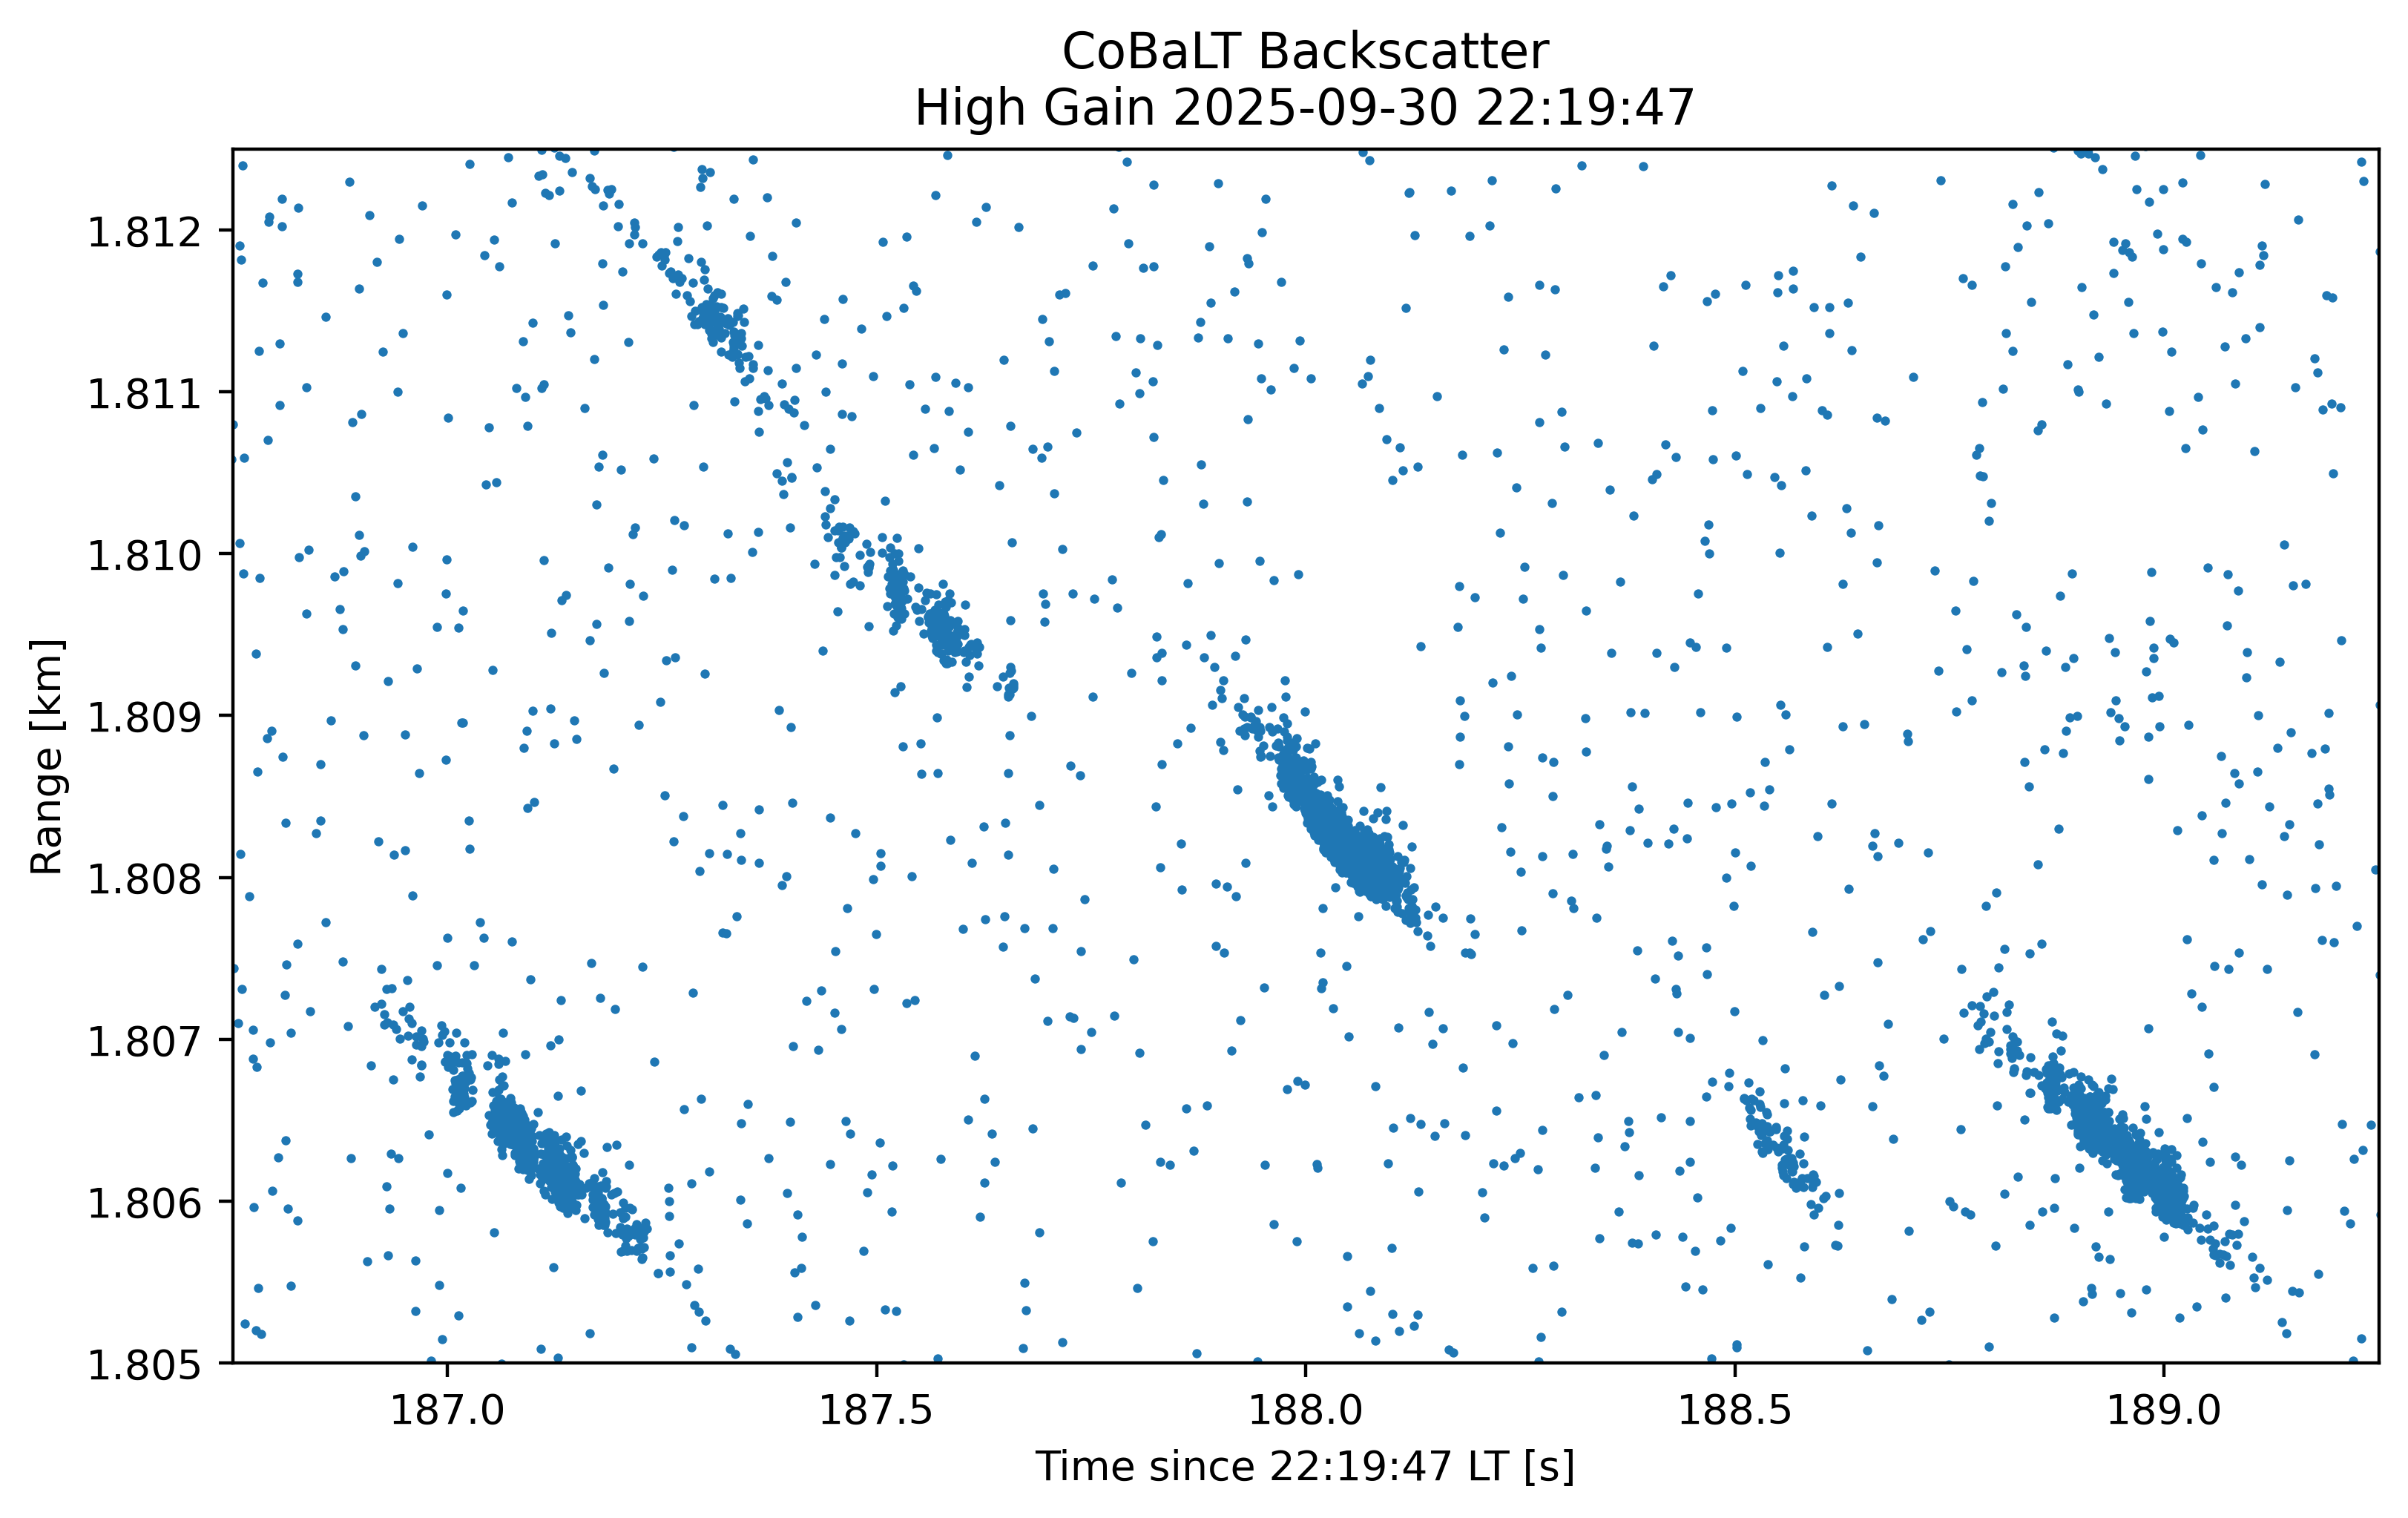

In [68]:
dp = DataPreprocessor(config)
dp.loader = DataLoader(config)
dp.plotter = DataPlotter(config)
dp.processor = DataProcessor(config)

dp.loader.preprocess()
dp.plotter.plot_scatter(dp.loader)

In [50]:
ranges = np.concatenate([da.values.ravel() for da in dp.loader.ranges_tot])
shots_time = np.concatenate([da.values.ravel() for da in dp.loader.shots_time_tot])

In [51]:
r0, r1 = dp.loader.ylim[0] * 1e3, dp.loader.ylim[1] * 1e3  # [km]
t0, t1 = dp.loader.xlim[0], dp.loader.xlim[1]  # [s]

mask = (
    (ranges >= r0) & (ranges <= r1) &
    (shots_time  >= t0) & (shots_time  <= t1)
)

filtered_ranges = ranges[mask]
filtered_times  = shots_time[mask]

print("Number of points: {}".format(filtered_ranges.size))

Number of points: 55493


In [52]:
CoBaLT_blobs = np.array([filtered_times, filtered_ranges]).T

In [53]:
X = torch.from_numpy(CoBaLT_blobs).float()

In [54]:
# k = 70
min_aspect_ratio = 2
min_cluster_size = 10

# nbrs = NearestNeighbors(n_neighbors=k).fit(X)
# dist, idx = nbrs.kneighbors(X)

X_scaled = np.zeros(X.shape)
tscale = t1 - t0  # [s]
rscale = r1 - r0  # [m]
X_scaled[:, 0] = X[:, 0] / tscale
X_scaled[:, 1] = X[:, 1] / rscale

r_unscaled = 0.33
r = r_unscaled / np.sqrt(rscale**2 + tscale**2)
print('Scaled radius value: {:.2e}'.format(r))
# r = 0.11

# nbrs = NearestNeighbors(radius=r).fit(X)
# dist, idx = nbrs.radius_neighbors(X)

nbrs = NearestNeighbors(radius=r).fit(X_scaled)
dist, idx = nbrs.radius_neighbors(X_scaled)

thetas = []
weights = []
noise_cnts = 0
continuous_cnts = 0

start = time.time()
for i in idx:    
    if len(i) < min_cluster_size:
        noise_cnts += 1
        continue  # need at least 2 points for PCA
    
    C = np.cov(X_scaled[i].T)
    w, v = np.linalg.eigh(C)
    
    L1, L2 = w
    
    aspect_ratio = L2 / L1
    
    # anisotropy rejection (reject noise)
    if aspect_ratio < min_aspect_ratio:
        continuous_cnts += 1
        continue
    
    major_ax = v[:, 1]  # major axis eigenvector
    theta = np.arctan2(major_ax[1], major_ax[0])
    
    thetas.append(theta)
    weights.append(aspect_ratio)
    
print('Time elapsed: {} s'.format(time.time() - start))
    
slopes = np.tan(np.array(thetas))
slopes *= (rscale / tscale)
# # Remove extreme outlier (usually min and max value)
# mask = (slopes != np.nanmin(slopes)) & (slopes != np.nanmax(slopes))
# slopes = slopes[mask]
# weights = np.array(weights)[mask]

noise_cnts_ratio = noise_cnts / len(idx)
continuous_cnts_ratio = continuous_cnts / len(idx)
print('Noise counts percentage: {:.2f}%'.format(noise_cnts_ratio * 100))
print('Continuous counts percentage: {:.2f}%'.format(continuous_cnts_ratio * 100))

Scaled radius value: 1.48e-02
Time elapsed: 3.6583189964294434 s
Noise counts percentage: 0.74%
Continuous counts percentage: 41.91%


In [55]:
# filter outlier slopes
min_val_slope, max_val_slope = -1000, 1000
mask = (slopes <= max_val_slope) & (slopes >= min_val_slope)  # valid slope range for binning
slopes = slopes[mask]
weights = np.array(weights)[mask]

if len(weights) > 0:
    avg_slope = np.average(slopes, weights=weights)
    print('Average slope: {:.2f} m/s'.format(avg_slope))
    
    slope_range = np.nanmax(slopes) - np.nanmin(slopes)
    print(slope_range)  

Average slope: -6.83 m/s
1962.9286535520573


In [58]:
if len(slopes) > 0:
    # To avoid infinite run time
    slope_range = np.nanmax(slopes) - np.nanmin(slopes)
    if slope_range > 200:
        binwidth = slope_range / 100
    else:
        binwidth = 0.5  # [m/s] precision

binwidth = 1
bin_edges = np.arange(np.nanmin(slopes), np.nanmax(slopes), binwidth) if (len(slopes) > 0) else np.arange(-100, 100, 1)
counts, edges = np.histogram(slopes, bins=bin_edges, range=(-1000, 1000), density=True)

dedge = np.diff(edges)[0]
slope_mode = edges[np.argmax(counts)] + (dedge / 2)  # [m/s]

print('Most common non-noise slope: {:.4f} m/s'.format(slope_mode))

Most common non-noise slope: -3.3376 m/s


Starting to save image...
Finished saving plot.
Time elapsed: 2.8 s


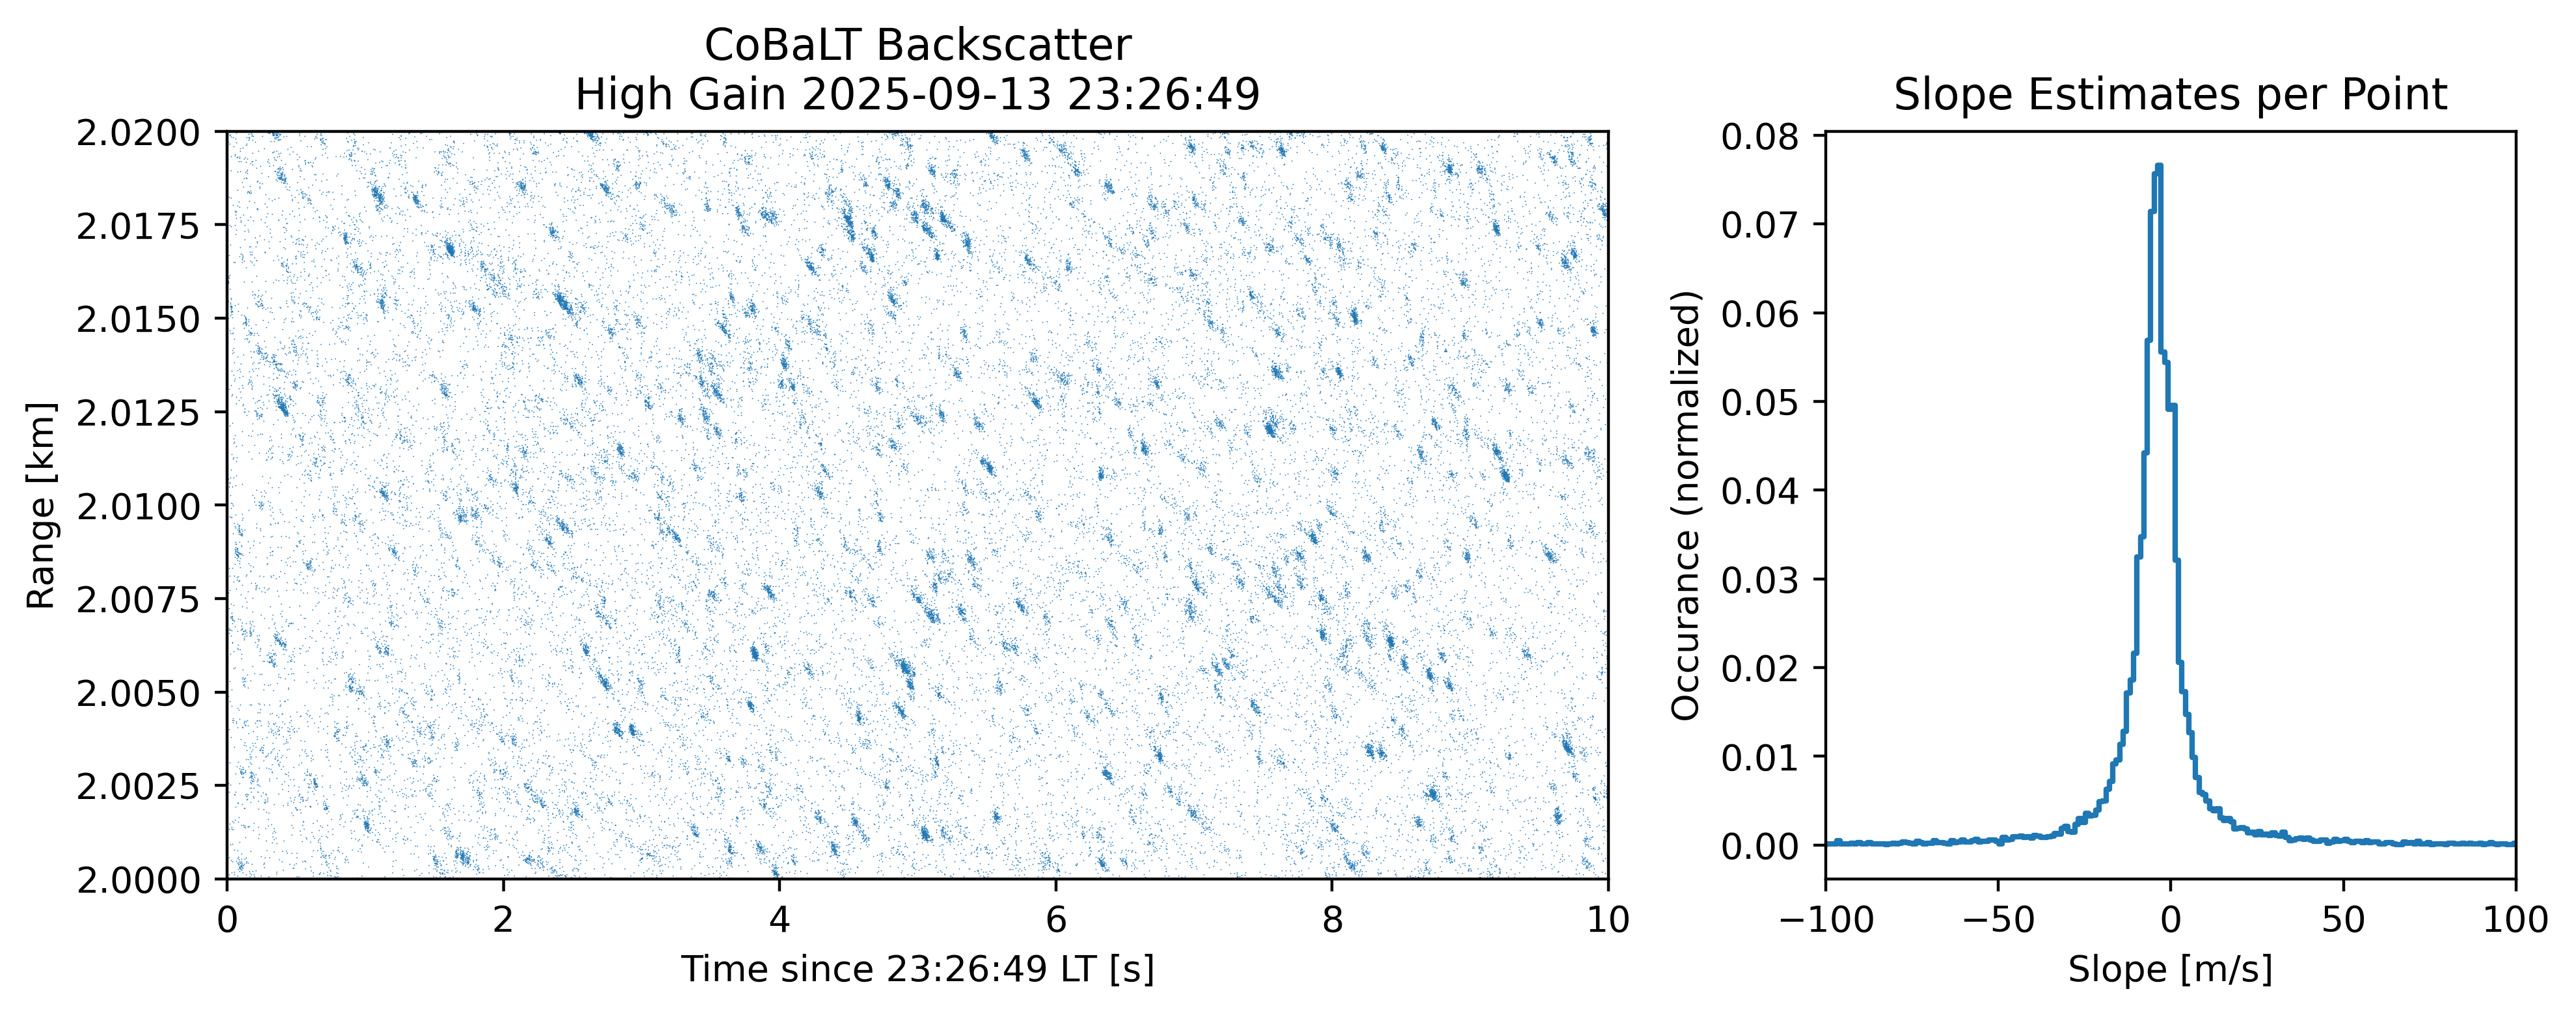

In [59]:
s = 0.1  # scatter dot size
figsize = (10, 4)

fig = plt.figure(dpi=400, figsize=figsize)
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])  # 2/3 and 1/3

ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[0])

# ax1 = fig.add_subplot(122)
ax1.step(edges[:-1], counts, where='post')
ax1.set_xlim([-100, 100])
ax1.set_xlabel('Slope [m/s]')
ax1.set_title('Slope Estimates per Point')
ax1.set_ylabel('Occurance (normalized)')

# ax2 = fig.add_subplot(121)
ax2.scatter(shots_time,
           ranges / 1e3,
           s=s,
           alpha=dp.plotter.alpha,
           linewidths=0
           )
ax2.set_ylim([dp.plotter.ylim[0], dp.plotter.ylim[1]]) if dp.plotter.plot_ylim else ax2.set_ylim([0, dp.plotter.c / 2 / dp.plotter.PRF / 1e3])
ax2.set_xlim([dp.plotter.xlim[0], dp.plotter.xlim[1]]) if dp.plotter.plot_xlim else None
ax2.set_xlabel('Time since {}:{}:{} LT [s]'.format(dp.loader.timestamp.hour,
                                                  dp.loader.timestamp.minute,
                                                  dp.loader.timestamp.second)
              )
ax2.set_ylabel('Range [km]')
ax2.set_title(
    'CoBaLT Backscatter\n{} {}'.format("Low Gain" if dp.loader.low_gain else "High Gain", dp.loader.timestamp)
)
plt.tight_layout()

print('Starting to save image...')
start = time.time()
img_fname = dp.loader.generic_fname + '_scatter' + '.png'
dp.loader.img_save_path = Path(dp.loader.data_dir + dp.loader.image_dir + dp.loader.date + '/covariance') / img_fname
fname = dp.loader.get_unique_filename(dp.loader.img_save_path)
fig.savefig(fname, dpi=dp.plotter.save_dpi)
print('Finished saving plot.\nTime elapsed: {:.1f} s'.format(time.time() - start))

plt.show()

# Bulk Covariance on a Scene

Now let's extend this method to estimate bulk covariance using a sliding window over a scene

In [2]:
# Load configuration and create the DataPreprocessor instance
config_path = project_root / 'config' / 'preprocessing_clustering.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

Detected Windows data directory: C:\Users\Grant\OneDrive - UCB-O365\ARSENL\Experiments\Cloud Measurements\First Light
Measurement time (behind 1 hour if outside Daylight Savings): 2025-09-13 23:26:49

Preprocessed data file(s) found. No need to create new one(s)...
Locating and loading relevant netcdf data chunks...

Including chunk #0: 0.00–32.97s overlaps 0.00–10.00s
File loaded.

✅ Full time range 0.00–10.00s covered by loaded chunks.
Loaded 1 files

Starting to generate scatter plot...
Finished generating plot.
Time elapsed: 2.3 s
Starting to save image...
Finished saving plot.
Time elapsed: 5.7 s


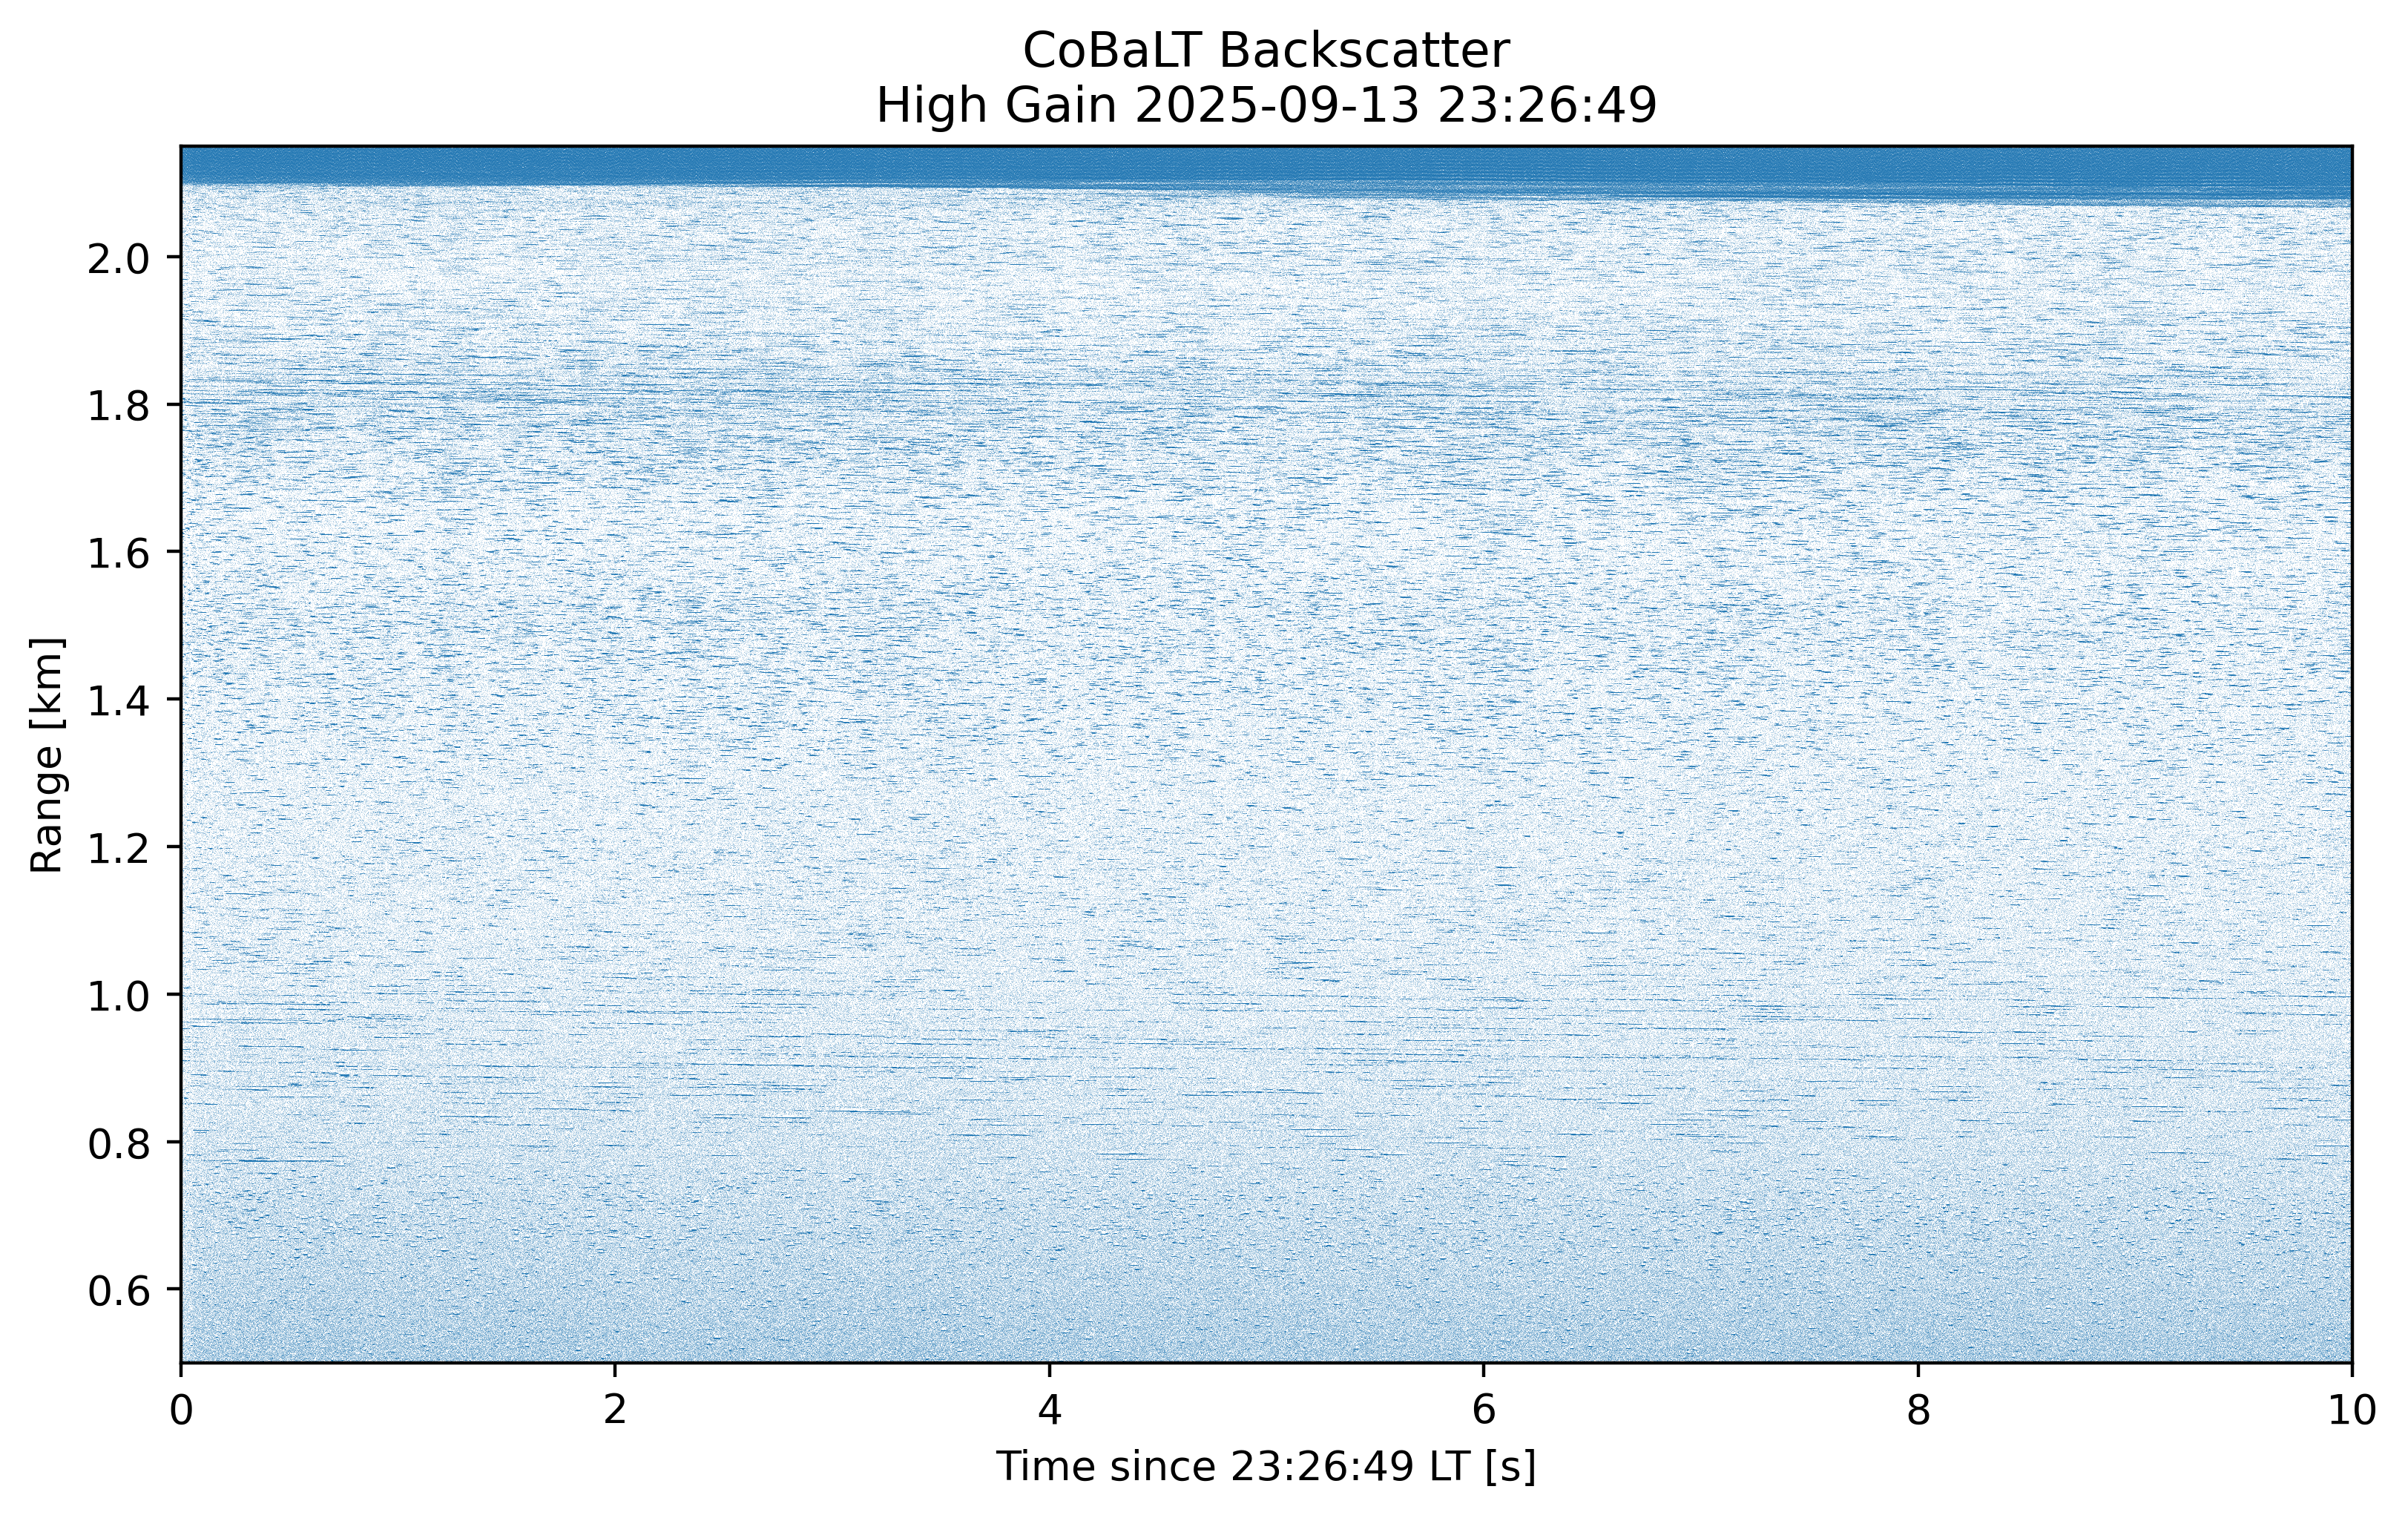

In [3]:
dp = DataPreprocessor(config)
dp.loader = DataLoader(config)
dp.plotter = DataPlotter(config)
dp.processor = DataProcessor(config)

dp.loader.preprocess()
dp.plotter.plot_scatter(dp.loader)

In [4]:
ranges = np.concatenate([da.values.ravel() for da in dp.loader.ranges_tot])
shots_time = np.concatenate([da.values.ravel() for da in dp.loader.shots_time_tot])

In [5]:
def mask_data(xlim, ylim, ranges, shots_time):
    r0, r1 = ylim[0] * 1e3, ylim[1] * 1e3  # [km]
    t0, t1 = xlim[0], xlim[1]  # [s]

    mask = (
        (ranges >= r0) & (ranges <= r1) &
        (shots_time  >= t0) & (shots_time  <= t1)
    )

    filtered_ranges = ranges[mask]
    filtered_times  = shots_time[mask]

    print("\nNumber of points: {}".format(filtered_ranges.size))
    
    return filtered_ranges, filtered_times

In [6]:
t_range = (dp.loader.xlim[0], dp.loader.xlim[1])  # [s]
r_range = (dp.loader.ylim[0], dp.loader.ylim[1])  # [km]

filtered_ranges_tot, filtered_times_tot = mask_data(t_range, r_range, ranges, shots_time)

w_rspan = 0.02  # [km]
w_tspan = 10  # [s]

w_redges = np.arange(r_range[0], r_range[1], w_rspan)  # [km]
w_tedges = np.arange(t_range[0], t_range[1] + w_tspan, w_tspan)  # [s]

min_aspect_ratio = 2
min_cluster_size = 10
min_val_slope, max_val_slope = -1000, 1000
slope_binwidth = 0.1  # [m/s]

w_num = len(w_redges) - 1 
print('Number of windows to estimate: {}\n'.format(w_num))


Number of points: 7513442
Number of windows to estimate: 82



In [19]:
slope_modes = np.zeros(w_num)
start_global = time.time()
for i in range(w_num):
    print('Window {}/{}'.format(i, w_num))
    
    xlim = (w_tedges[0], w_tedges[1])  # [s]
    ylim = (w_redges[i], w_redges[i+1])  # [km]
    
    filtered_ranges, filtered_times = mask_data(xlim, ylim, ranges, shots_time)
    
    CoBaLT_blobs = np.array([filtered_times, filtered_ranges]).T
    X = torch.from_numpy(CoBaLT_blobs).float()
    
    X_scaled = np.zeros(X.shape)
    tscale = xlim[1] - xlim[0]  # [s]
    rscale = (ylim[1] - ylim[0]) * 1e3  # [m]
    X_scaled[:, 0] = X[:, 0] / tscale
    X_scaled[:, 1] = X[:, 1] / rscale

    r_unscaled = 0.33
    r = r_unscaled / np.sqrt(rscale**2 + tscale**2)

    nbrs = NearestNeighbors(radius=r).fit(X_scaled)
    dist, idx = nbrs.radius_neighbors(X_scaled)

    thetas = []
    weights = []
    noise_cnts = 0
    continuous_cnts = 0

    start = time.time()
    for j in idx:    
        if len(j) < min_cluster_size:
            noise_cnts += 1
            continue  # need at least 2 points for PCA

        C = np.cov(X_scaled[j].T)
        w, v = np.linalg.eigh(C)

        L1, L2 = w

        aspect_ratio = L2 / L1

        # anisotropy rejection (reject noise)
        if aspect_ratio < min_aspect_ratio:
            continuous_cnts += 1
            continue

        major_ax = v[:, 1]  # major axis eigenvector
        theta = np.arctan2(major_ax[1], major_ax[0])

        thetas.append(theta)
        weights.append(aspect_ratio)

    print('Time elapsed: {} s'.format(time.time() - start))

    slopes = np.tan(np.array(thetas))
    slopes *= (rscale / tscale)

    noise_cnts_ratio = noise_cnts / len(idx)
    continuous_cnts_ratio = continuous_cnts / len(idx)
    print('Noise counts percentage: {:.2f}%'.format(noise_cnts_ratio * 100))
    print('Continuous counts percentage: {:.2f}%'.format(continuous_cnts_ratio * 100))
    
    # filter outlier slopes
    mask = (slopes <= max_val_slope) & (slopes >= min_val_slope)  # valid slope range for binning
    slopes = slopes[mask]
    weights = np.array(weights)[mask]

    bin_edges = np.arange(np.nanmin(slopes), np.nanmax(slopes), slope_binwidth) if (len(slopes) > 0) else np.arange(-100, 100, 1)
    counts, edges = np.histogram(slopes, bins=bin_edges, range=(-1000, 1000), density=True)

    dedge = np.diff(edges)[0]
    slope_mode = edges[np.argmax(counts)] + (dedge / 2)  # [m/s]
    slope_modes[i] = slope_mode
    
    print('Most common non-noise slope: {:.4f} m/s'.format(slope_mode))
    
print('\nTotal time elapsed: {:.2f} s'.format(time.time() - start_global))

Window 0/82

Number of points: 120265
Time elapsed: 11.798912763595581 s
Noise counts percentage: 0.00%
Continuous counts percentage: 94.68%
Most common non-noise slope: 0.2829 m/s
Window 1/82

Number of points: 114476
Time elapsed: 11.153604745864868 s
Noise counts percentage: 0.00%
Continuous counts percentage: 93.60%
Most common non-noise slope: -0.0002 m/s
Window 2/82

Number of points: 111329
Time elapsed: 10.429576396942139 s
Noise counts percentage: 0.00%
Continuous counts percentage: 91.02%
Most common non-noise slope: 0.0835 m/s
Window 3/82

Number of points: 106923
Time elapsed: 14.331856489181519 s
Noise counts percentage: 0.00%
Continuous counts percentage: 89.88%
Most common non-noise slope: 0.0432 m/s
Window 4/82

Number of points: 100153
Time elapsed: 9.929380655288696 s
Noise counts percentage: 0.00%
Continuous counts percentage: 90.09%
Most common non-noise slope: -0.1903 m/s
Window 5/82

Number of points: 99526
Time elapsed: 9.915795803070068 s
Noise counts percentage


Number of points: 75944
Time elapsed: 7.194952964782715 s
Noise counts percentage: 0.43%
Continuous counts percentage: 28.97%
Most common non-noise slope: -10.5002 m/s
Window 47/82

Number of points: 80465
Time elapsed: 7.739816665649414 s
Noise counts percentage: 0.37%
Continuous counts percentage: 26.73%
Most common non-noise slope: -3.1318 m/s
Window 48/82

Number of points: 75717
Time elapsed: 6.833119630813599 s
Noise counts percentage: 0.36%
Continuous counts percentage: 30.45%
Most common non-noise slope: -2.4894 m/s
Window 49/82

Number of points: 84329
Time elapsed: 8.934384822845459 s
Noise counts percentage: 0.35%
Continuous counts percentage: 27.92%
Most common non-noise slope: -2.8938 m/s
Window 50/82

Number of points: 77247
Time elapsed: 7.78919243812561 s
Noise counts percentage: 0.33%
Continuous counts percentage: 30.02%
Most common non-noise slope: -8.0037 m/s
Window 51/82

Number of points: 80228
Time elapsed: 8.42006540298462 s
Noise counts percentage: 0.37%
Contin

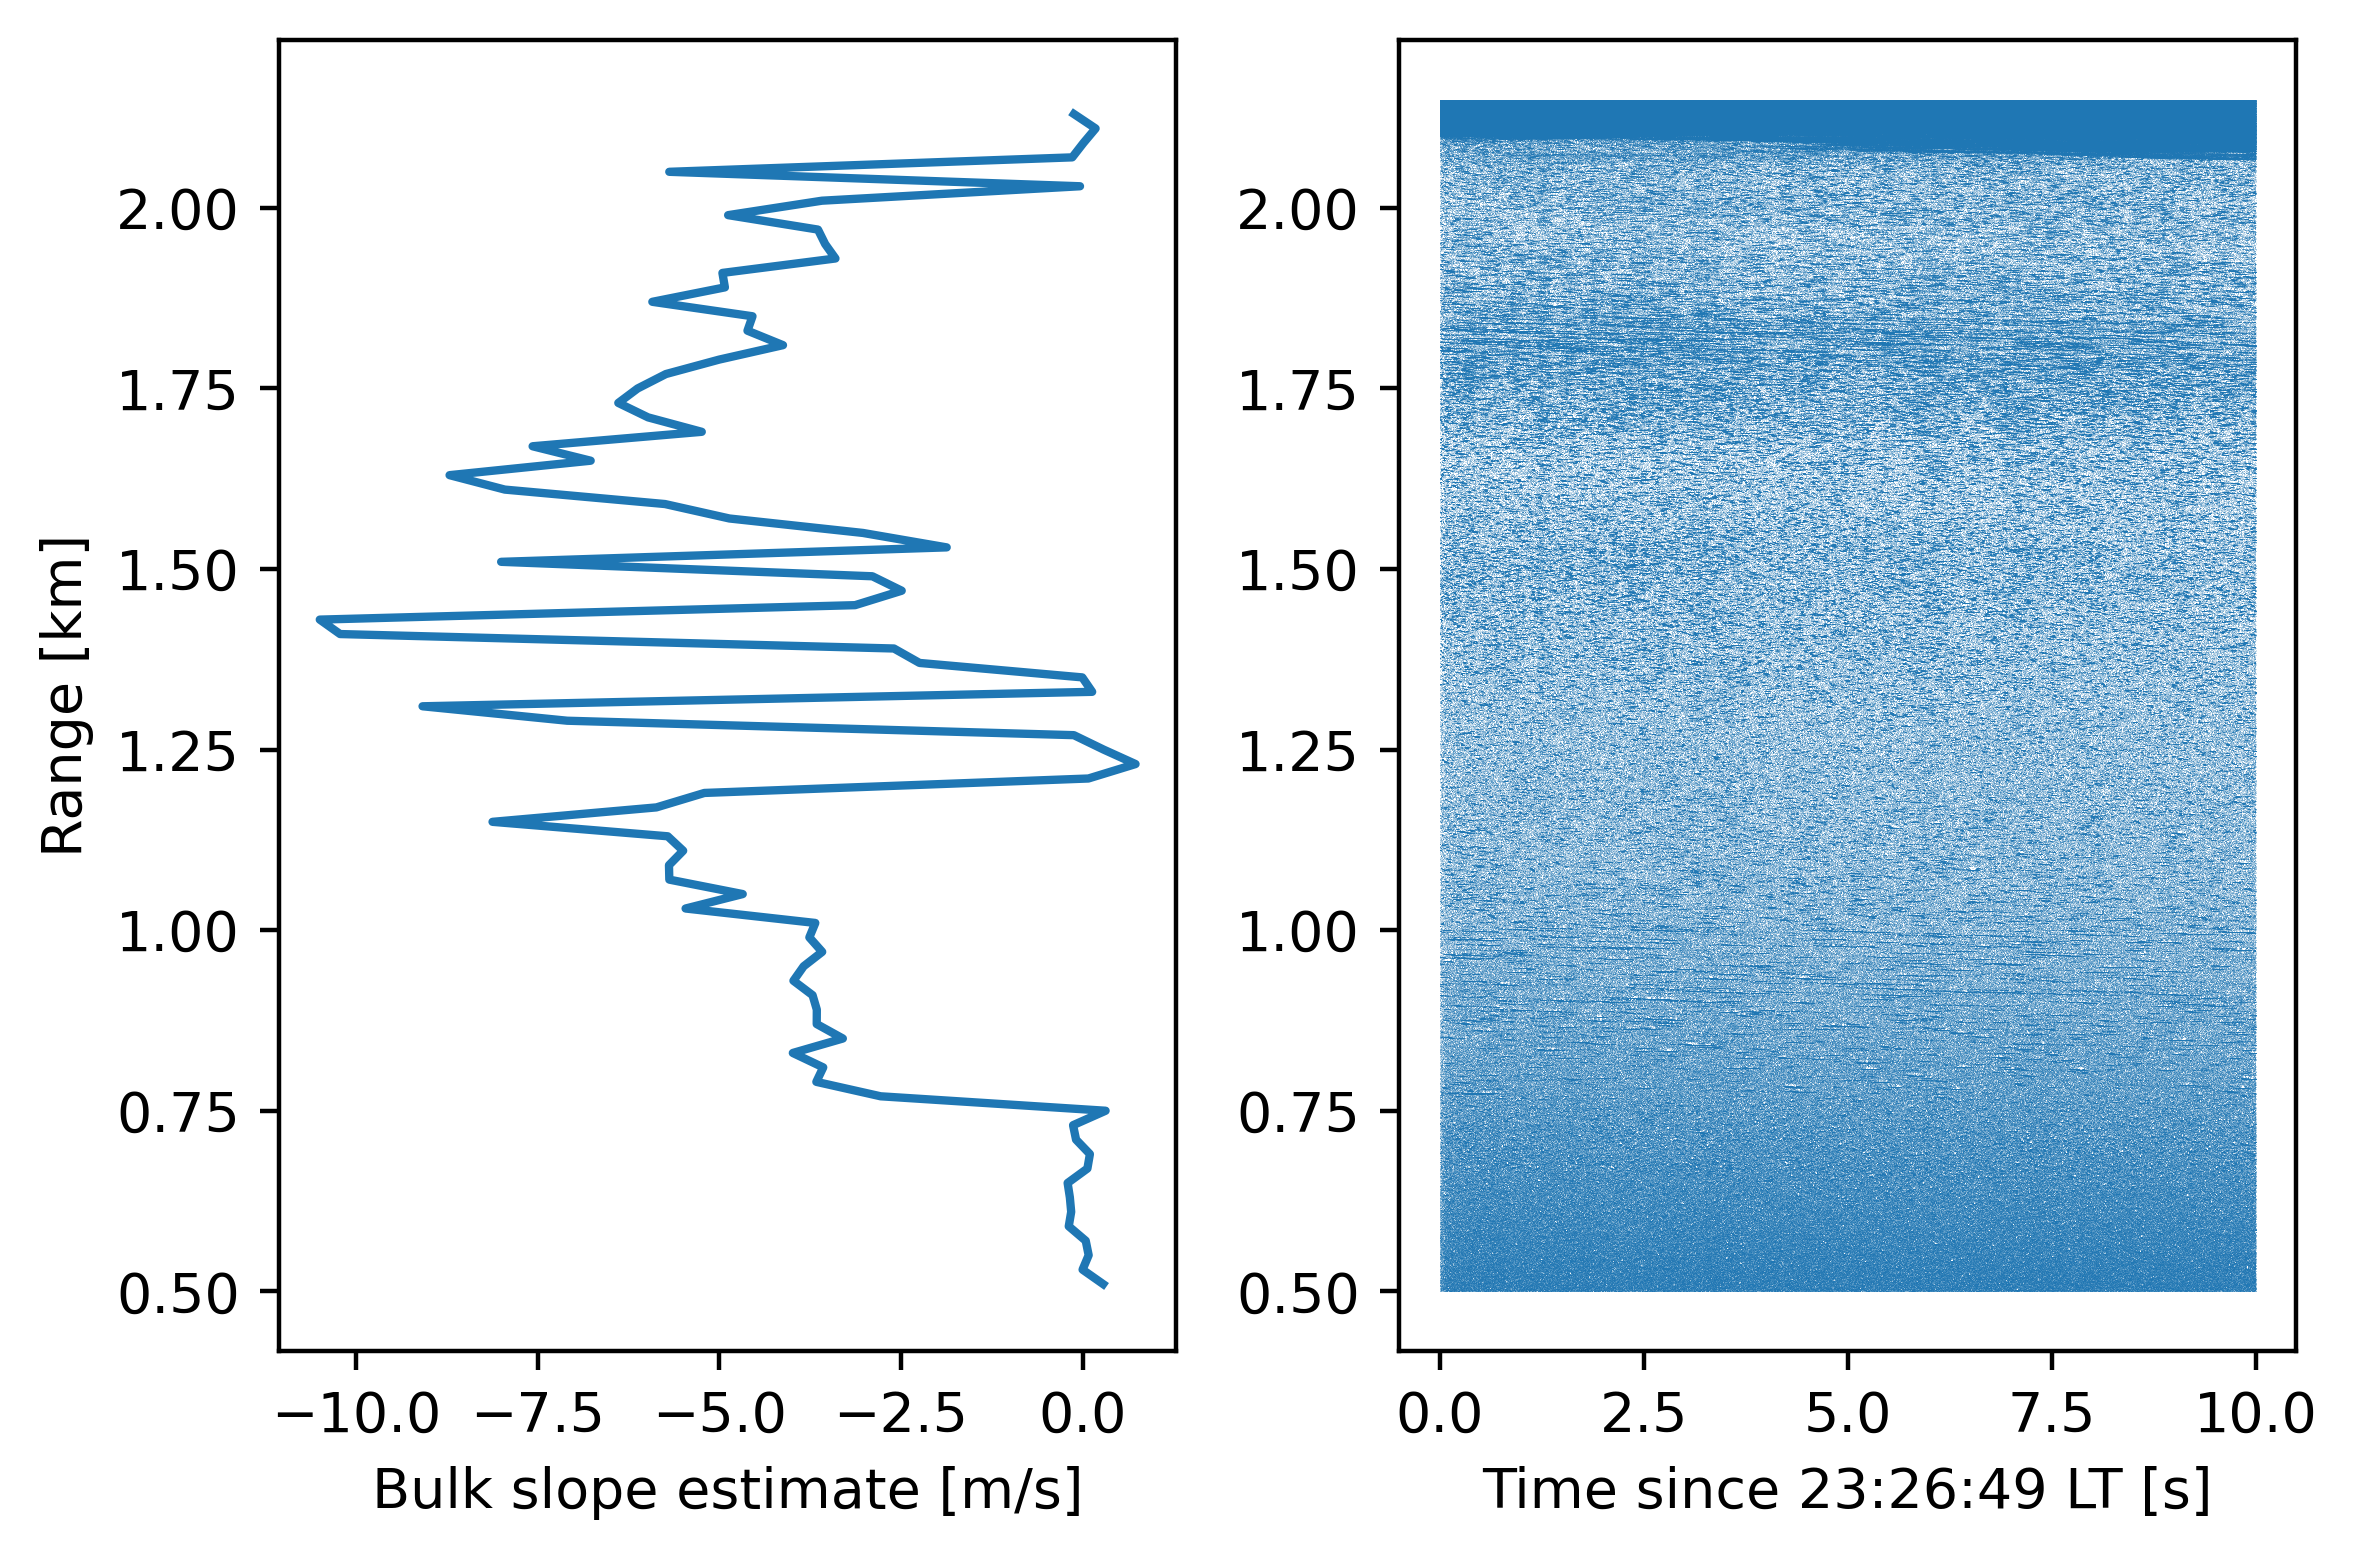

In [26]:
dr = np.diff(w_redges)[0]
w_rcenters = w_redges[:-1] + dr / 2  # [km]
y_lines = w_redges  # [km]

fig = plt.figure(dpi=400)

ax2 = fig.add_subplot(122)
ax1 = fig.add_subplot(121, sharey=ax2)

ax1.plot(slope_modes, w_rcenters, '-', linewidth='1.5')
# ax1.set_ylim([filtered_ranges_tot.min()/1e3, filtered_ranges_tot.max()/1e3])
ax1.set_ylabel('Range [km]')
ax1.set_xlabel('Bulk slope estimate [m/s]')

ax2.scatter(filtered_times_tot, filtered_ranges_tot/1e3, s=dp.plotter.dot_size, alpha=dp.plotter.alpha, linewidths=0)
# ax2.hlines(
#     y=y_lines,
#     xmin=filtered_times_tot.min(),
#     xmax=filtered_times_tot.max(),
#     colors='k',
#     linewidth=0.5,
#     alpha=0.3
# )
ax2.set_xlabel('Time since {}:{}:{} LT [s]'.format(dp.loader.timestamp.hour,
                                                  dp.loader.timestamp.minute,
                                                  dp.loader.timestamp.second)
             )
# ax2.set_ylabel('Range [km]')
plt.tight_layout()
plt.show()